Distribution summary:
        metric         mean  median     p90     p95      p99  maximum
Price (₹ lakh)   399.505392   262.0   766.0  1101.0  2860.00  12263.0
   Area (sqft)  2621.660105  2015.0  4430.0  5790.0  9157.00 958320.0
 Rate per sqft 15295.214482 12379.0 22000.0 27855.0 69416.08 310000.0


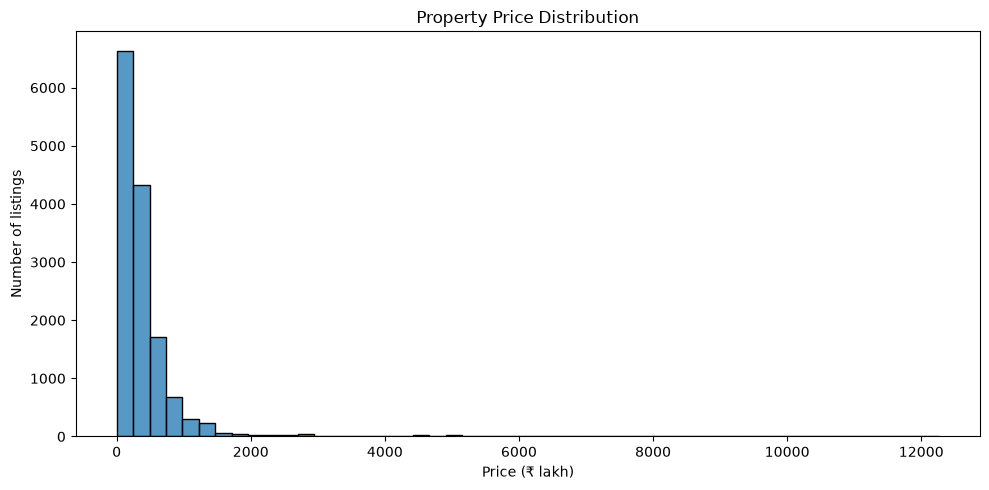

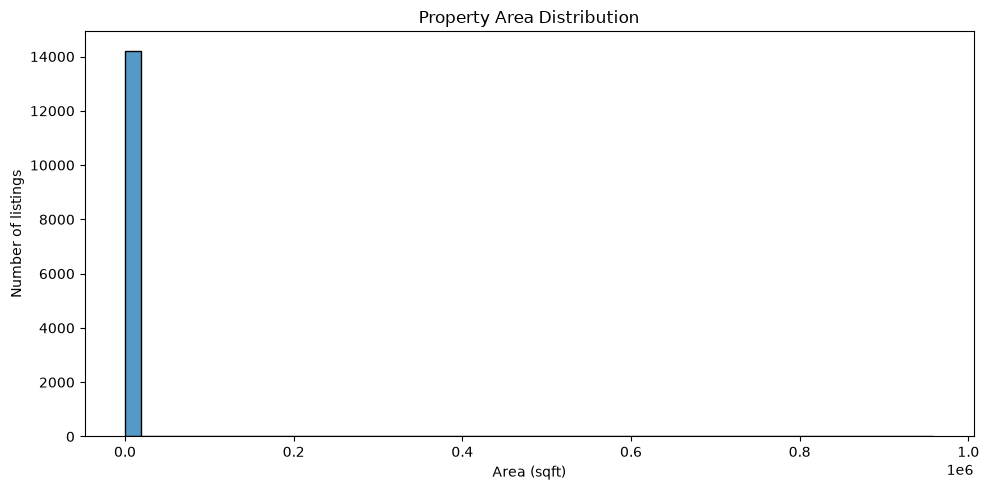

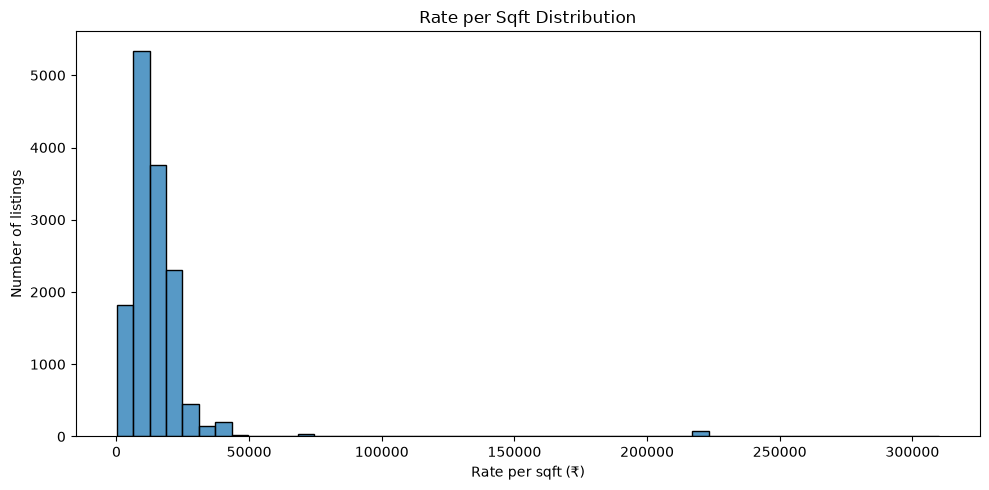


Price band distribution:
            listings  share_pct
price_band                     
Below 50L        908       6.38
50L-1Cr         1241       8.72
1Cr-2Cr         3343      23.50
2Cr-5Cr         5578      39.21
5Cr-10Cr        2315      16.27
Above 10Cr       840       5.91


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

project_folder = Path.cwd()

if project_folder.name == "notebooks":
    project_folder = project_folder.parent

data_folder = project_folder / "data"
feature_file = data_folder / "propertylens_featured.csv"

df = pd.read_csv(feature_file)

# Distribution summary
distribution_summary = pd.DataFrame({
    "metric": ["Price (₹ lakh)", "Area (sqft)", "Rate per sqft"],
    "mean": [
        df["price_lakh"].mean(),
        df["area_sqft"].mean(),
        df["rate_per_sqft"].mean()
    ],
    "median": [
        df["price_lakh"].median(),
        df["area_sqft"].median(),
        df["rate_per_sqft"].median()
    ],
    "p90": [
        df["price_lakh"].quantile(0.90),
        df["area_sqft"].quantile(0.90),
        df["rate_per_sqft"].quantile(0.90)
    ],
    "p95": [
        df["price_lakh"].quantile(0.95),
        df["area_sqft"].quantile(0.95),
        df["rate_per_sqft"].quantile(0.95)
    ],
    "p99": [
        df["price_lakh"].quantile(0.99),
        df["area_sqft"].quantile(0.99),
        df["rate_per_sqft"].quantile(0.99)
    ],
    "maximum": [
        df["price_lakh"].max(),
        df["area_sqft"].max(),
        df["rate_per_sqft"].max()
    ]
})

print("Distribution summary:")
print(distribution_summary.to_string(index=False))


# Price distribution
plt.figure(figsize=(10, 5))
sns.histplot(df["price_lakh"], bins=50)
plt.xlabel("Price (₹ lakh)")
plt.ylabel("Number of listings")
plt.title("Property Price Distribution")
plt.tight_layout()
plt.show()


# Area distribution
plt.figure(figsize=(10, 5))
sns.histplot(df["area_sqft"], bins=50)
plt.xlabel("Area (sqft)")
plt.ylabel("Number of listings")
plt.title("Property Area Distribution")
plt.tight_layout()
plt.show()


# Rate per sqft distribution
plt.figure(figsize=(10, 5))
sns.histplot(df["rate_per_sqft"], bins=50)
plt.xlabel("Rate per sqft (₹)")
plt.ylabel("Number of listings")
plt.title("Rate per Sqft Distribution")
plt.tight_layout()
plt.show()


# Price band distribution
price_band_counts = (
    df["price_band"]
    .value_counts()
    .reindex([
        "Below 50L",
        "50L-1Cr",
        "1Cr-2Cr",
        "2Cr-5Cr",
        "5Cr-10Cr",
        "Above 10Cr"
    ])
)

price_band_pct = (
    price_band_counts
    .div(len(df))
    .mul(100)
    .round(2)
)

price_band_summary = pd.DataFrame({
    "listings": price_band_counts,
    "share_pct": price_band_pct
})

print("\nPrice band distribution:")
print(price_band_summary.to_string())